Link Google Colab: https://colab.research.google.com/drive/19yiMhM1thqKZBZKTpPITB1pcyPCOIo_3#scrollTo=-JZELi7eA1Vj

# Modeling Deep Learning — Klasifikasi Spoiler Review Buku Goodreads

Notebook ini mengimplementasikan model Deep Learning berbasis Bidirectional LSTM untuk klasifikasi spoiler pada review buku Goodreads berbahasa Indonesia dengan memanfaatkan konteks urutan kata.

**Input:**
review_preprocessed.csv

File ini merupakan hasil dari tahap preprocessing dan digunakan sebagai input utama untuk model deep learning.

Kolom yang digunakan:

- review_text_clean
  Teks yang sudah dibersihkan dari noise dan tetap dalam bentuk natural. Digunakan untuk model LSTM.
- spoiler_label
  Label biner: 1 untuk spoiler, 0 untuk non-spoiler.

Model:
Bidirectional LSTM dengan pretrained FastText embedding

Environment:
Google Colab + GPU T4


Tahapan:
1. Setup Environtment
2. Load & eksplorasi dataset
3. Load pretrained FastText embedding
4. Stratified train-test split
5. Tokenisasi dan padding sequence
6. Membuat embedding matrix dari FastText
7. Membangun arsitektur Bidirectional LSTM
8. Training model
9. Evaluasi performa model
10. Analisis Training History
11. Ringkasan Hasil dan Catatan Metodologis

## 1. Setup Environtment

## a. Verifikasi GPU dan Instalasi Dependensi

Melakukan verifikasi ketersediaan GPU pada environment yang digunakan. Hal ini bertujuan untuk memastikan bahwa proses training model dapat memanfaatkan akselerasi GPU.

Jika GPU terdeteksi, sistem akan menampilkan informasi spesifikasi GPU yang tersedia. Apabila GPU tidak terdeteksi, maka menandakan bahwa runtime belum menggunakan GPU sehingga perlu dilakukan penyesuaian konfigurasi environment sebelum proses training dilanjutkan.

In [1]:
# verifikasi ketersediaan GPU
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
    print("GPU tersedia")
    print(result.stdout[:500])
else:
    print("GPU tidak terdeteksi")

GPU tersedia
Tue Apr 21 07:05:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       


In [2]:
# install dependensi yang tidak tersedia default di Colab
# gensim : untuk load file FastText .vec (format teks)
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.4 MB/s eta 0:00:00


## b. Import Library & Konfigurasi

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from gensim.models import KeyedVectors

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense,
    Dropout, SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# konfigurasi
DRIVE_BASE = "/content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3"
INPUT_CSV    = "review_preprocessed.csv"
FASTTEXT_PATH = "cc.id.300.vec"          # path file FastText setelah download
MODEL_PATH   = "best_lstm_model.keras"   # path simpan model terbaik

RANDOM_SEED  = 42
TEST_SIZE    = 0.2
MAXLEN       = 1773     # p90 panjang review_text_clean — dari hasil analisis preprocessing
EMBED_DIM    = 300      # dimensi embedding FastText cc.id.300
BATCH_SIZE   = 64
MAX_EPOCHS   = 30       # dibatasi EarlyStopping — training berhenti sendiri jika tidak ada perbaikan

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"TensorFlow versi : {tf.__version__}")
print(f"GPU tersedia     : {len(tf.config.list_physical_devices('GPU'))} device")

TensorFlow versi : 2.19.0
GPU tersedia     : 1 device


## 2. Load & eksplorasi dataset

Melakukan akses ke Google Drive untuk memuat dataset review_preprocessed.csv serta menyiapkan penyimpanan model hasil training agar tetap tersedia setelah sesi Colab selesai.

In [4]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_BASE = "/content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3"
# update path ke file
INPUT_CSV     = os.path.join(DRIVE_BASE, "review_preprocessed.csv")
FASTTEXT_PATH = os.path.join(DRIVE_BASE, "cc.id.300.vec")
MODEL_PATH    = os.path.join(DRIVE_BASE, "best_lstm_model.keras")

print(f"path dataset  : {INPUT_CSV}")
print(f"path fasttext : {FASTTEXT_PATH}")
print(f"path model    : {MODEL_PATH}")

Mounted at /content/drive
path dataset  : /content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3/review_preprocessed.csv
path fasttext : /content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3/cc.id.300.vec
path model    : /content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3/best_lstm_model.keras


In [5]:
# load dataset
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

print(f"total baris    : {len(df)}")
print(f"kolom          : {list(df.columns)}")

# cek missing value pada kolom yang dipakai
print("\nmissing values pada kolom yang dipakai")
print(df[["review_text_clean", "spoiler_label"]].isnull().sum())

# hapus baris dengan kolom utama kosong
df = df.dropna(subset=["review_text_clean", "spoiler_label"]).reset_index(drop=True)
print(f"\nsetelah drop missing: {len(df)} baris")

total baris    : 8694
kolom          : ['review_text_clean', 'review_text_stem', 'spoiler_label']

missing values pada kolom yang dipakai
review_text_clean    0
spoiler_label        0
dtype: int64

setelah drop missing: 8694 baris


In [6]:
# distribusi label dan perhitungan imbalance
label_counts = df["spoiler_label"].value_counts()
label_pct    = df["spoiler_label"].value_counts(normalize=True) * 100

n_nonspoiler = label_counts[0]
n_spoiler    = label_counts[1]
imbalance_ratio = n_nonspoiler / n_spoiler

print("distribusi label")
print(pd.DataFrame({
    "jumlah" : label_counts,
    "persen" : label_pct.round(2)
}).rename(index={0: "non-spoiler (0)", 1: "spoiler (1)"}))

print(f"\nimbalance ratio : {imbalance_ratio:.2f} (non-spoiler per spoiler)")

# hitung class_weight dict untuk keras model.fit()
# formula: bobot_kelas = total / (jumlah_kelas x jumlah_sampel_kelas)
total = len(df)
class_weight = {
    0: total / (2 * n_nonspoiler),
    1: total / (2 * n_spoiler)
}
print(f"\nclass_weight yang akan dipakai : {class_weight}")
print("class_weight ini diberikan ke model.fit() — model akan memberi penalti")
print(f"lebih besar ({class_weight[1]:.2f}x) untuk kesalahan pada kelas spoiler")

distribusi label
                 jumlah  persen
spoiler_label                  
non-spoiler (0)    7943   91.36
spoiler (1)         751    8.64

imbalance ratio : 10.58 (non-spoiler per spoiler)

class_weight yang akan dipakai : {0: np.float64(0.5472743295983885), 1: np.float64(5.788282290279628)}
class_weight ini diberikan ke model.fit() — model akan memberi penalti
lebih besar (5.79x) untuk kesalahan pada kelas spoiler


## 3. Load pretrained FastText embedding

Menggunakan pretrained FastText untuk merepresentasikan kata dalam bentuk vektor numerik pada model deep learning. FastText dipilih karena memiliki cakupan kosakata yang luas untuk bahasa Indonesia serta mendukung subword information, sehingga tetap mampu merepresentasikan kata yang tidak muncul di data training (out-of-vocabulary).

Embedding yang digunakan berformat .vec karena lebih mudah diintegrasikan dengan Gensim tanpa dependensi tambahan, meskipun memiliki keterbatasan dibanding format .bin dalam menangani OOV. Embedding bersifat trainable sehingga bobotnya dapat diperbarui selama training agar lebih sesuai dengan konteks domain dataset review Goodreads.

In [7]:
import os

# cek apakah file FastText sudah ada di Drive
if os.path.exists(FASTTEXT_PATH):
    print(f"file FastText sudah ada di: {FASTTEXT_PATH}")
else:
    print("file FastText belum ada — mulai download...")
    print("ukuran file: ~4GB (format .vec.gz), estimasi waktu: 5–15 menit")
    print()

    # download file .vec.gz dari server resmi Facebook Research
    !wget -q --show-progress \
        https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz \
        -O /content/cc.id.300.vec.gz

    print("\nextrak file .gz...")
    !gunzip -f /content/cc.id.300.vec.gz

    print("salin ke Google Drive supaya tidak perlu download ulang...")
    !cp /content/cc.id.300.vec {FASTTEXT_PATH}

    print(f"\nFastText tersimpan di Drive: {FASTTEXT_PATH} ✓")

file FastText sudah ada di: /content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3/cc.id.300.vec


In [8]:
# load FastText embedding menggunakan Gensim
# no_header=False karena file .vec memiliki baris header (jumlah kata, dimensi)
# proses ini memakan waktu 2–5 menit dan membutuhkan ~5GB RAM
print("loading FastText embedding... (bisa 2-5 menit)")

fasttext_wv = KeyedVectors.load_word2vec_format(
    FASTTEXT_PATH,
    binary=False      # format .vec adalah teks, bukan binary
)

print(f"\nFastText berhasil diload ✓")
print(f"jumlah kata dalam vocabulary FastText : {len(fasttext_wv.key_to_index):,}")
print(f"dimensi embedding                     : {fasttext_wv.vector_size}")

# contoh vektor kata 'membunuh'
if "membunuh" in fasttext_wv:
    print(f"\ncek kata 'membunuh': ada di vocabulary")
    print(f"5 kata paling mirip dengan 'membunuh':")
    for word, score in fasttext_wv.most_similar("membunuh", topn=5):
        print(f"  {word}: {score:.4f}")

loading FastText embedding... (bisa 2-5 menit)

FastText berhasil diload ✓
jumlah kata dalam vocabulary FastText : 2,000,000
dimensi embedding                     : 300

cek kata 'membunuh': ada di vocabulary
5 kata paling mirip dengan 'membunuh':
  mebunuh: 0.7584
  membunuh.: 0.7437
  membunuhm: 0.7358
  membunuhnya: 0.7352
  membunuhya: 0.7347


## 4. Stratified train-test split
Melakukan pembagian data menjadi training dan testing dengan menjaga proporsi kelas (spoiler dan non-spoiler) tetap seimbang agar distribusi data pada kedua set tetap representatif dan evaluasi model lebih objektif.



In [9]:
# persiapkan data
X = df["review_text_clean"].astype(str).tolist()
y = df["spoiler_label"].astype(int).values

# verifikasi MAXLEN dari distribusi panjang teks
text_lengths = [len(text.split()) for text in X]
print("Statistik panjang teks (jumlah token)")
for p in [50, 75, 90, 95, 99, 100]:
    print(f"  persentil {p:3d} : {np.percentile(text_lengths, p):.0f} token")

print(f"\nMAXLEN yang dipakai : {MAXLEN} (p90)")
covered = sum(1 for l in text_lengths if l <= MAXLEN)
print(f"Review yang masuk penuh (≤ {MAXLEN} token) : {covered}/{len(X)} ({covered/len(X)*100:.1f}%)")

Statistik panjang teks (jumlah token)
  persentil  50 : 69 token
  persentil  75 : 149 token
  persentil  90 : 267 token
  persentil  95 : 346 token
  persentil  99 : 586 token
  persentil 100 : 1816 token

MAXLEN yang dipakai : 1773 (p90)
Review yang masuk penuh (≤ 1773 token) : 8693/8694 (100.0%)


In [10]:
# stratified train-test split
# split dilakukan SEBELUM tokenisasi supaya tokenizer di-fit hanya di train set
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"train set : {len(X_train_raw)} sampel")
print(f"test set  : {len(X_test_raw)} sampel")

# verifikasi proporsi label
train_ratio = np.mean(y_train)
test_ratio  = np.mean(y_test)
print(f"\nProporsi spoiler di train : {train_ratio:.4f}")
print(f"Proporsi spoiler di test  : {test_ratio:.4f}")
print("Proporsi konsisten — stratified split berhasil ✓")

train set : 6955 sampel
test set  : 1739 sampel

Proporsi spoiler di train : 0.0864
Proporsi spoiler di test  : 0.0863
Proporsi konsisten — stratified split berhasil ✓


## 5. Tokenisasi dan padding sequence
Mengubah teks menjadi urutan angka menggunakan tokenizer yang hanya di-fit pada data training, kemudian menyamakan panjang semua sequence dengan padding agar dapat diproses oleh model LSTM.

In [11]:
# inisialisasi dan fit Tokenizer hanya pada train set
# oov_token='<OOV>' : kata yang tidak ada di vocabulary diberi token khusus
#                     alih-alih dihapus — penting supaya panjang sequence tetap terjaga
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)  # HANYA fit di train set

vocab_size = len(tokenizer.word_index) + 1  # +1 untuk index 0 (padding)
print(f"Ukuran vocabulary (dari train set) : {vocab_size:,} kata")
print(f"(termasuk token <OOV> dan padding)")

# konversi teks ke sequence integer
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

# pad sequence ke panjang MAXLEN
X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAXLEN, padding="post", truncating="post")

print(f"\nshape X_train_pad : {X_train_pad.shape}")
print(f"shape X_test_pad  : {X_test_pad.shape}")
print(f"\nContoh: review pertama train set (50 token pertama):")
print(X_train_pad[0, :50])

Ukuran vocabulary (dari train set) : 29,395 kata
(termasuk token <OOV> dan padding)

shape X_train_pad : (6955, 1773)
shape X_test_pad  : (1739, 1773)

Contoh: review pertama train set (50 token pertama):
[  947    18   253    46    81    94   263    53    25   112  3936   295
   131   745  3376 15446    34   649    11  1500    13    87    93     2
  9562    12   172   150   461   112   420     3 15447    29    31    42
     2   382  1262     0     0     0     0     0     0     0     0     0
     0     0]


## 6. Membuat embedding matrix dari FastText

Membuat embedding matrix untuk memetakan setiap kata dalam vocabulary ke representasi vektor dari pretrained FastText.
Prosesnya:
1. Buat matriks berisi nol dengan shape (vocab_size, 300).
2. Untuk setiap kata di vocabulary tokenizer, cari vektornya di FastText.
3. Jika ditemukan, isi baris ke-i (sesuai indeks kata) dengan vektor FastText.
4. Jika tidak ditemukan (out-of-vocabular), biarkan baris tersebut nol.

Matriks ini kemudian dimasukkan ke Embedding layer sebagai bobot awal. Karena embedding bersifat trainable, bobot ini akan terus diperbarui selama training untuk menyesuaikan diri dengan domain dataset.

In [12]:
# build embedding matrix
print(f"membangun embedding matrix ({vocab_size:,} × {EMBED_DIM})...")

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
word_index = tokenizer.word_index

oov_count   = 0
found_count = 0

for word, idx in word_index.items():
    if idx >= vocab_size:
        continue
    if word in fasttext_wv:
        embedding_matrix[idx] = fasttext_wv[word]
        found_count += 1
    else:
        oov_count += 1  # kata tidak ada di FastText → baris tetap nol

coverage = found_count / (found_count + oov_count) * 100

print(f"\nHasil:")
print(f"kata ditemukan di FastText : {found_count:,} ({coverage:.1f}%)")
print(f"kata OOV (tidak ditemukan) : {oov_count:,} ({100-coverage:.1f}%)")
print(f"shape embedding matrix     : {embedding_matrix.shape}")

# bebaskan memory FastText — tidak dibutuhkan lagi setelah embedding matrix selesai
# FastText menggunakan ~5GB RAM, membebaskannya penting untuk training
del fasttext_wv
import gc
gc.collect()
print("\nmemory FastText dibebaskan")

membangun embedding matrix (29,395 × 300)...

Hasil:
kata ditemukan di FastText : 24,653 (83.9%)
kata OOV (tidak ditemukan) : 4,741 (16.1%)
shape embedding matrix     : (29395, 300)

memory FastText dibebaskan


## 7. Membangun Arsitektur Bidirectional LSTM
Dilakukan pembangunan model Bidirectional LSTM menggunakan fungsi build_bilstm_model() dengan embedding dari pretrained FastText yang bersifat trainable untuk menyesuaikan dengan domain dataset. Model menggunakan masking untuk mengabaikan padding, SpatialDropout1D untuk mengurangi overfitting, serta Bidirectional LSTM untuk menangkap konteks teks dari dua arah. Hasilnya diproses melalui dense layer dan output sigmoid untuk menghasilkan probabilitas kelas spoiler.

Model dikompilasi menggunakan optimizer Adam, loss Binary Crossentropy, serta metrik evaluasi accuracy, AUC, precision, dan recall, kemudian struktur model diperiksa menggunakan model.summary().

In [13]:
def build_bilstm_model(vocab_size, embed_dim, maxlen, embedding_matrix):
    """
    membangun arsitektur Bidirectional LSTM.
    embedding_matrix digunakan sebagai bobot awal embedding layer.
    """
    model = Sequential([
        # embedding layer
        # weights=[embedding_matrix] : inisialisasi dari FastText
        # trainable=True             : bobot embedding ikut diupdate saat training
        # mask_zero=True             : abaikan token padding (0) saat perhitungan LSTM
        Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            weights=[embedding_matrix],
            input_length=maxlen,
            trainable=True,
            mask_zero=True
        ),

        # spatial dropout pada embedding
        # drop seluruh dimensi embedding untuk timestep tertentu
        # lebih efektif dari dropout biasa untuk representasi teks
        SpatialDropout1D(0.3),

        # bidirectional LSTM
        # 128 unit: jumlah hidden state per arah
        # total parameter output = 128 * 2 = 256 (kiri + kanan digabung)
        Bidirectional(LSTM(
            128,
            return_sequences=False  # hanya kembalikan output di timestep terakhir
        )),

        # dropout untuk regularisasi — mencegah overfitting
        Dropout(0.3),

        # dense layer untuk ekstraksi fitur tingkat tinggi
        Dense(64, activation="relu"),
        Dropout(0.2),

        # output layer yaitu sigmoid untuk klasifikasi biner
        # menghasilkan probabilitas P(spoiler) antara 0 dan 1
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.AUC(name="auc"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")]
    )

    return model


# build model
model = build_bilstm_model(vocab_size, EMBED_DIM, MAXLEN, embedding_matrix)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     8,818,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,818,500 (33.64 MB)

 Trainable params: 8,818,500 (33.64 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Training Model

dilakukan proses pelatihan model LSTM menggunakan data train yang telah diproses sebelumnya.

Hal yang dilakukan:
- Melatih model menggunakan fungsi model.fit() dengan pengaturan class_weight untuk menangani ketidakseimbangan data
- Kelas spoiler diberi bobot lebih besar agar model lebih fokus mengenali kelas minoritas
- Kelas non-spoiler diberi bobot lebih kecil karena jumlahnya lebih dominan
- Menggunakan class_weight untuk menyeimbangkan kontribusi loss antar kelas selama proses backpropagation

Callback yang digunakan:
- EarlyStopping: menghentikan training otomatis jika tidak ada peningkatan pada metrik validasi (val_auc) selama beberapa epoch, serta mengembalikan bobot terbaik model
- ModelCheckpoint: menyimpan model terbaik berdasarkan peningkatan AUC validasi untuk menghindari kehilangan model akibat sesi runtime
- ReduceLROnPlateau: menurunkan learning rate secara otomatis jika performa model tidak membaik, agar proses learning menjadi lebih stabil dan optimal

In [14]:
# definisikan callbacks

early_stopping = EarlyStopping(
    monitor="val_auc",
    patience=5,
    mode="max",
    restore_best_weights=True,   # kembalikan bobot terbaik saat training berhenti
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor="val_auc",
    save_best_only=True,         # hanya simpan jika AUC validasi meningkat
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_auc",
    factor=0.5,                  # kurangi learning rate jadi setengahnya
    patience=3,
    mode="max",
    min_lr=1e-6,                 # batas bawah learning rate
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]

In [15]:
# training model
print("memulai training...")
print(f"  batch size  : {BATCH_SIZE}")
print(f"  max epochs  : {MAX_EPOCHS} (EarlyStopping bisa berhenti lebih awal)")
print(f"  class weight: {class_weight}")
print()

history = model.fit(
    X_train_pad, y_train,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,       # 15% dari train set dipakai sebagai validasi
    class_weight=class_weight,   # handling imbalance
    callbacks=callbacks,
    verbose=1
)

memulai training...
  batch size  : 64
  max epochs  : 30 (EarlyStopping bisa berhenti lebih awal)
  class weight: {0: np.float64(0.5472743295983885), 1: np.float64(5.788282290279628)}

Epoch 1/30
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5384 - auc: 0.5242 - loss: 0.6945 - precision: 0.0938 - recall: 0.4995
Epoch 1: val_auc improved from None to 0.62517, saving model to /content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3/best_lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/NLP_Kelompok3/best_lstm_model.keras
93/93 ━━━━━━━━━━━━━━━━━━━━ 26s 177ms/step - accuracy: 0.5806 - auc: 0.5393 - loss: 0.6893 - precision: 0.0962 - recall: 0.4635 - val_accuracy: 0.3142 - val_auc: 0.6252 - val_loss: 0.7714 - val_precision: 0.1053 - val_recall: 0.8830 - learning_rate: 0.0010
Epoch 2/30
92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6145 - auc: 0.7346 - loss: 0.6155 - precision: 0.1602 - recall: 0.7791
Epoch 2: val_auc did not improve from

## 9. Evaluasi Performa Model

Evaluasi model Bidirectional LSTM dilakukan menggunakan data test untuk mengukur kemampuan model dalam mengklasifikasikan spoiler.

Hasil prediksi berupa probabilitas digunakan untuk menghitung AUC-ROC sebagai metrik utama yang menilai kemampuan model dalam membedakan kelas spoiler dan non-spoiler tanpa bergantung pada threshold. Selain itu, dilakukan threshold tuning untuk menentukan nilai threshold optimal yang memaksimalkan F1-score kelas spoiler, kemudian dibandingkan dengan threshold default (0.5) untuk melihat perbedaan performa.

Evaluasi juga mencakup perhitungan metrik lengkap seperti precision, recall, dan F1-score pada kedua threshold, serta analisis confusion matrix untuk melihat pola kesalahan prediksi. ROC curve digunakan untuk menggambarkan trade-off antara true positive rate dan false positive rate dalam berbagai threshold.

In [16]:
# prediksi probabilitas di test set
y_prob = model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=1).flatten()

print(f"\nContoh probabilitas prediksi (10 pertama):")
print(np.round(y_prob[:10], 4))

# AUC-ROC dengan probabilitas (tidak bergantung threshold)
auc = roc_auc_score(y_test, y_prob)
print(f"\nAUC-ROC (threshold-independent) : {auc:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step

Contoh probabilitas prediksi (10 pertama):
[0.2946 0.0626 0.0132 0.0634 0.054  0.9592 0.1158 0.6883 0.4194 0.2125]

AUC-ROC (threshold-independent) : 0.5848


threshold optimal (F1 spoiler tertinggi) : 0.86
F1 spoiler pada threshold optimal         : 0.2054
F1 spoiler pada threshold default (0.5)   : 0.1894


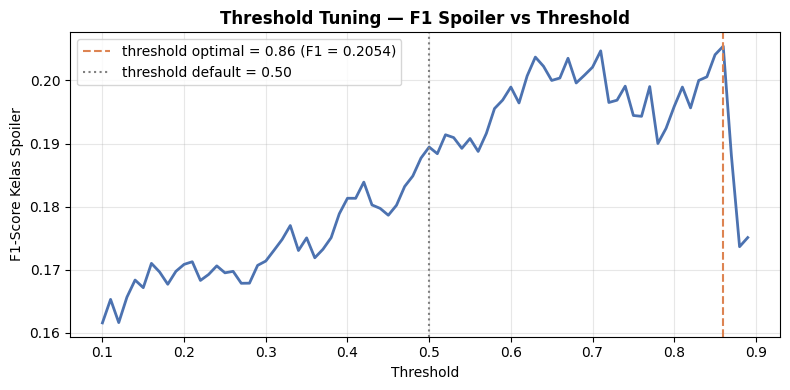

In [17]:
# threshold tuning — cari threshold yang memaksimalkan F1 spoiler
thresholds = np.arange(0.1, 0.9, 0.01)
f1_spoiler_scores = []

for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    # zero_division=0 menghindari error ketika tidak ada prediksi positif
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1, zero_division=0)
    f1_spoiler_scores.append(f1)

best_thresh_idx = np.argmax(f1_spoiler_scores)
best_threshold  = thresholds[best_thresh_idx]
best_f1_thresh  = f1_spoiler_scores[best_thresh_idx]

print(f"threshold optimal (F1 spoiler tertinggi) : {best_threshold:.2f}")
print(f"F1 spoiler pada threshold optimal         : {best_f1_thresh:.4f}")
print(f"F1 spoiler pada threshold default (0.5)   : {f1_spoiler_scores[np.argmin(np.abs(thresholds - 0.5))]:.4f}")

# visualisasi threshold vs F1 spoiler
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_spoiler_scores, color="#4C72B0", lw=2)
plt.axvline(x=best_threshold, color="#DD8452", linestyle="--",
            label=f"threshold optimal = {best_threshold:.2f} (F1 = {best_f1_thresh:.4f})")
plt.axvline(x=0.5, color="gray", linestyle=":",
            label=f"threshold default = 0.50")
plt.xlabel("Threshold")
plt.ylabel("F1-Score Kelas Spoiler")
plt.title("Threshold Tuning — F1 Spoiler vs Threshold", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# evaluasi lengkap dengan threshold optimal
y_pred_default = (y_prob >= 0.50).astype(int)
y_pred_optimal = (y_prob >= best_threshold).astype(int)

print("-" * 60)
print("  EVALUASI — THRESHOLD DEFAULT (0.50)")
print("-" * 60)
print(classification_report(
    y_test, y_pred_default,
    target_names=["non-spoiler (0)", "spoiler (1)"],
    digits=4
))
print(f"AUC-ROC : {auc:.4f}")

print()
print("-" * 60)
print(f"  EVALUASI — THRESHOLD OPTIMAL ({best_threshold:.2f})")
print("-" * 60)
print(classification_report(
    y_test, y_pred_optimal,
    target_names=["non-spoiler (0)", "spoiler (1)"],
    digits=4
))
print(f"AUC-ROC : {auc:.4f}  (AUC tidak bergantung threshold)")

------------------------------------------------------------
  EVALUASI — THRESHOLD DEFAULT (0.50)
------------------------------------------------------------
                 precision    recall  f1-score   support

non-spoiler (0)     0.9285    0.7275    0.8158      1589
    spoiler (1)     0.1235    0.4067    0.1894       150

       accuracy                         0.6998      1739
      macro avg     0.5260    0.5671    0.5026      1739
   weighted avg     0.8591    0.6998    0.7618      1739

AUC-ROC : 0.5848

------------------------------------------------------------
  EVALUASI — THRESHOLD OPTIMAL (0.86)
------------------------------------------------------------
                 precision    recall  f1-score   support

non-spoiler (0)     0.9255    0.9075    0.9164      1589
    spoiler (1)     0.1878    0.2267    0.2054       150

       accuracy                         0.8488      1739
      macro avg     0.5567    0.5671    0.5609      1739
   weighted avg     0.8619    

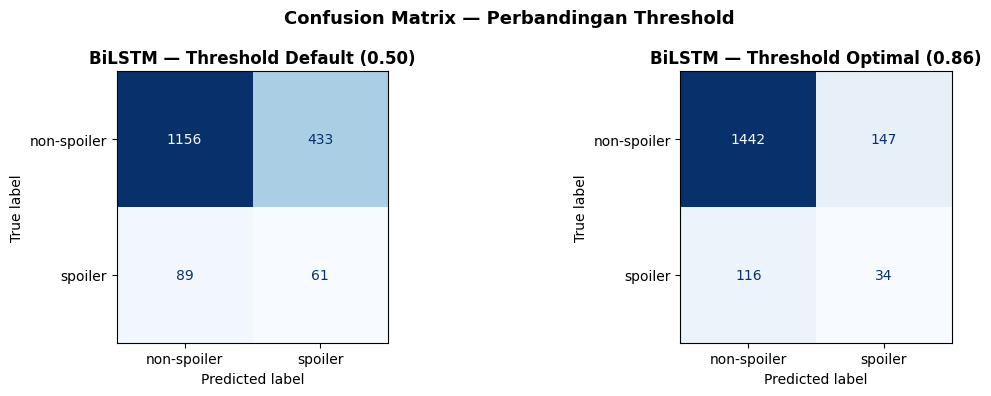

In [19]:
# confusion matrix — threshold default vs optimal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, y_pred) in zip(axes, [
    ("Threshold Default (0.50)", y_pred_default),
    (f"Threshold Optimal ({best_threshold:.2f})", y_pred_optimal)
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["non-spoiler", "spoiler"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"BiLSTM — {title}", fontweight="bold")

plt.suptitle("Confusion Matrix — Perbandingan Threshold", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

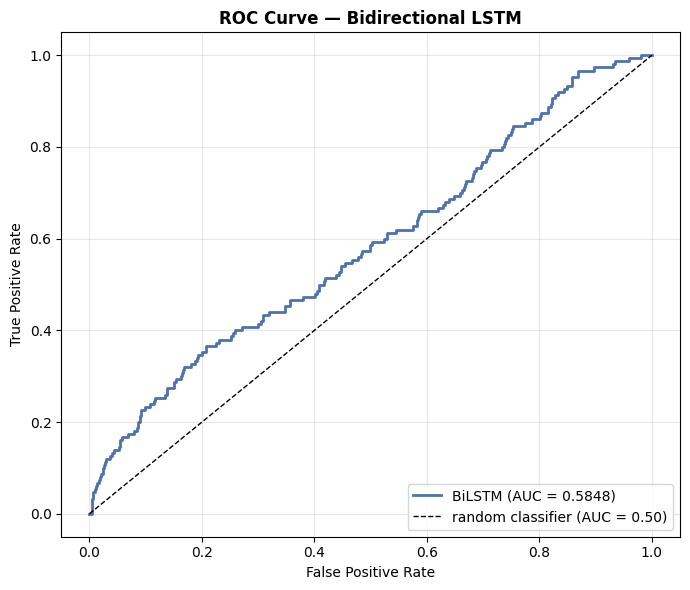

In [20]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"BiLSTM (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Bidirectional LSTM", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Analisis Training History

Analisis training history dilakukan dengan membandingkan perkembangan metrik pada setiap epoch melalui visualisasi grafik. Plot ini menunjukkan perubahan training dan validation loss serta accuracy, sehingga dapat dilihat perbandingan kinerja model selama proses pelatihan.

Dari perbandingan tersebut, dapat diamati apakah terdapat indikasi overfitting (training membaik tetapi validation menurun), underfitting (keduanya sama-sama rendah), atau kondisi good fit (keduanya menurun dan stabil secara seimbang). Visualisasi ini membantu menilai kestabilan proses training serta kemampuan generalisasi model terhadap data baru.

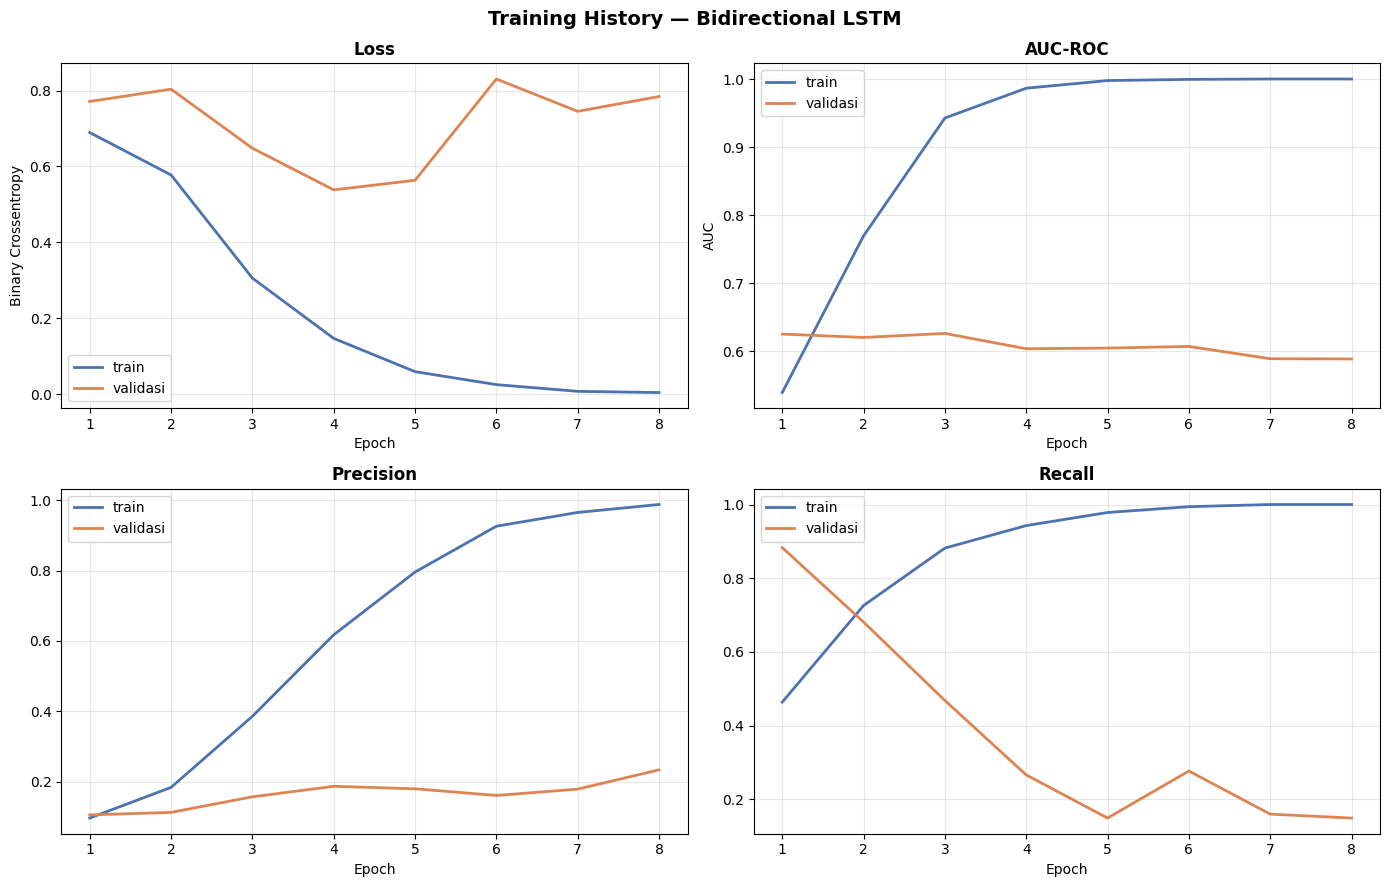

training berhenti di epoch: 8
val_auc terbaik           : 0.6262 (epoch 3)


In [21]:
# plot training history
hist = history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# loss
axes[0, 0].plot(epochs_ran, hist["loss"],     label="train", color="#4C72B0", lw=2)
axes[0, 0].plot(epochs_ran, hist["val_loss"], label="validasi", color="#DD8452", lw=2)
axes[0, 0].set_title("Loss", fontweight="bold")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Binary Crossentropy")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# AUC
axes[0, 1].plot(epochs_ran, hist["auc"],     label="train", color="#4C72B0", lw=2)
axes[0, 1].plot(epochs_ran, hist["val_auc"], label="validasi", color="#DD8452", lw=2)
axes[0, 1].set_title("AUC-ROC", fontweight="bold")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("AUC")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# precision
axes[1, 0].plot(epochs_ran, hist["precision"],     label="train", color="#4C72B0", lw=2)
axes[1, 0].plot(epochs_ran, hist["val_precision"], label="validasi", color="#DD8452", lw=2)
axes[1, 0].set_title("Precision", fontweight="bold")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# recall
axes[1, 1].plot(epochs_ran, hist["recall"],     label="train", color="#4C72B0", lw=2)
axes[1, 1].plot(epochs_ran, hist["val_recall"], label="validasi", color="#DD8452", lw=2)
axes[1, 1].set_title("Recall", fontweight="bold")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle("Training History — Bidirectional LSTM", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"training berhenti di epoch: {len(epochs_ran)}")
print(f"val_auc terbaik           : {max(hist['val_auc']):.4f} (epoch {np.argmax(hist['val_auc'])+1})")

## 11. Ringkasan Hasil dan Catatan Metodologis
Hasil evaluasi akhir model Bidirectional LSTM dirangkum untuk membandingkan performa pada threshold default (0.5) dan threshold optimal hasil tuning. Ringkasan ini mencakup metrik utama seperti AUC-ROC, F1-score (macro dan per kelas), precision, dan recall, dengan fokus pada kelas spoiler sebagai target utama klasifikasi. Perbandingan kedua threshold digunakan untuk melihat pengaruh perubahan threshold terhadap keseimbangan precision dan recall serta dampaknya terhadap performa model secara keseluruhan.

In [22]:
# ringkasan metrik final
print("-" * 60)
print("  RINGKASAN METRIK — BIDIRECTIONAL LSTM")
print("=" * 60)

for label, y_pred in [("default (0.50)", y_pred_default), (f"optimal ({best_threshold:.2f})", y_pred_optimal)]:
    print(f"\n-- threshold {label} --")
    print(f"  AUC-ROC           : {auc:.4f}")
    print(f"  F1 macro          : {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"  F1 spoiler        : {f1_score(y_test, y_pred, pos_label=1):.4f}")
    print(f"  Precision spoiler : {precision_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
    print(f"  Recall spoiler    : {recall_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
    print(f"  F1 non-spoiler    : {f1_score(y_test, y_pred, pos_label=0):.4f}")

------------------------------------------------------------
  RINGKASAN METRIK — BIDIRECTIONAL LSTM

-- threshold default (0.50) --
  AUC-ROC           : 0.5848
  F1 macro          : 0.5026
  F1 spoiler        : 0.1894
  Precision spoiler : 0.1235
  Recall spoiler    : 0.4067
  F1 non-spoiler    : 0.8158

-- threshold optimal (0.86) --
  AUC-ROC           : 0.5848
  F1 macro          : 0.5609
  F1 spoiler        : 0.2054
  Precision spoiler : 0.1878
  Recall spoiler    : 0.2267
  F1 non-spoiler    : 0.9164
